In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [81]:
# Load the dataset
data = pd.read_csv("PALreviews2.csv")
print("Loaded: PALreviews2.csv")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Loaded: PALreviews2.csv
Rows: 891, Columns: 15


In [82]:
data.head()

,Unnamed: 0,Aircraft,Type Of Traveller,Trip Verified,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended
0,0,NaN,Solo Leisure,Yes,Business Class,Manila to Melbourne,2022-11-01,0.0,0.0,0.0,0.0,1.0,1,0.0,no
1,1,A321 / A330,Couple Leisure,Yes,Business Class,Singapore to Melbourne via Manila,2022-10-01,2.0,3.0,2.0,2.0,1.0,3,0.0,no
2,2,NaN,Couple Leisure,Yes,Economy Class,Los Angeles to Manila,2022-04-01,0.0,0.0,0.0,0.0,0.0,3,0.0,no
3,3,NaN,Solo Leisure,No,Economy Class,Manila to San Francisco,2022-11-01,1.0,1.0,1.0,1.0,1.0,1,1.0,no
4,4,NaN,Family Leisure,Yes,Economy Class,Canada to Philippines,2022-11-01,3.0,3.0,3.0,3.0,1.0,1,3.0,no


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              891 non-null    int64  
 1   Aircraft                229 non-null    object 
 2   Type Of Traveller       891 non-null    object 
 3   Trip Verified           891 non-null    object 
 4   Seat Type               891 non-null    object 
 5   Route                   883 non-null    object 
 6   Date Flown              891 non-null    object 
 7   Seat Comfort            891 non-null    float64
 8   Cabin Staff Service     891 non-null    float64
 9   Food & Beverages        891 non-null    float64
 10  Inflight Entertainment  891 non-null    float64
 11  Ground Service          891 non-null    float64
 12  Value For Money         891 non-null    int64  
 13  Wifi & Connectivity     891 non-null    float64
 14  Recommended             891 non-null    ob

In [84]:
data.describe()

,Unnamed: 0,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,445.000000,2.248036,2.544332,1.887767,1.352413,1.873176,2.274972,0.686869
std,257.353842,1.549260,1.744010,1.580349,1.610828,1.555226,1.386788,1.160025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,222.500000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
50%,445.000000,2.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000
75%,667.500000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,1.000000
max,890.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# Data cleaning

##### Remove col 1

In [85]:
# Drop the first column
data = data.drop(data.columns[0], axis=1)

# Saving modified CSV
data.to_csv("PALreview2_index0dropped.csv", index=False)

##### Standardize column names

In [86]:
#Remove extra spaces from column names - clean column names
data.columns = data.columns.str.strip().str.replace("  ", " ")

##### Replace common missing-value labels

In [87]:
missing_values = ["NA"]
data = data.replace(missing_values, np.nan)
data

,Aircraft,Type Of Traveller,Trip Verified,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended
0,NaN,Solo Leisure,Yes,Business Class,Manila to Melbourne,2022-11-01,0.0,0.0,0.0,0.0,1.0,1,0.0,no
1,A321 / A330,Couple Leisure,Yes,Business Class,Singapore to Melbourne via Manila,2022-10-01,2.0,3.0,2.0,2.0,1.0,3,0.0,no
2,NaN,Couple Leisure,Yes,Economy Class,Los Angeles to Manila,2022-04-01,0.0,0.0,0.0,0.0,0.0,3,0.0,no
3,NaN,Solo Leisure,No,Economy Class,Manila to San Francisco,2022-11-01,1.0,1.0,1.0,1.0,1.0,1,1.0,no
4,NaN,Family Leisure,Yes,Economy Class,Canada to Philippines,2022-11-01,3.0,3.0,3.0,3.0,1.0,1,3.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,A330,Solo Leisure,No,Economy Class,Riyadh to Manila,2020-01-01,3.0,5.0,5.0,0.0,5.0,5,4.0,yes
887,A330-300,Business,Yes,Economy Class,Melbourne to Manila,2020-01-01,4.0,5.0,5.0,4.0,2.0,5,4.0,yes
888,NaN,Solo Leisure,Yes,Economy Class,London to Kuala Lumpur via Manila,2020-03-01,0.0,0.0,0.0,0.0,0.0,1,0.0,no
889,NaN,Solo Leisure,Yes,Economy Class,Manila to Bacolod,2020-02-01,4.0,4.0,0.0,0.0,1.0,3,0.0,no


##### Using pandas date format

In [88]:
# Convert date column
data["Date Flown"] = pd.to_datetime(data["Date Flown"], errors="coerce")
data

,Aircraft,Type Of Traveller,Trip Verified,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended
0,NaN,Solo Leisure,Yes,Business Class,Manila to Melbourne,2022-11-01,0.0,0.0,0.0,0.0,1.0,1,0.0,no
1,A321 / A330,Couple Leisure,Yes,Business Class,Singapore to Melbourne via Manila,2022-10-01,2.0,3.0,2.0,2.0,1.0,3,0.0,no
2,NaN,Couple Leisure,Yes,Economy Class,Los Angeles to Manila,2022-04-01,0.0,0.0,0.0,0.0,0.0,3,0.0,no
3,NaN,Solo Leisure,No,Economy Class,Manila to San Francisco,2022-11-01,1.0,1.0,1.0,1.0,1.0,1,1.0,no
4,NaN,Family Leisure,Yes,Economy Class,Canada to Philippines,2022-11-01,3.0,3.0,3.0,3.0,1.0,1,3.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,A330,Solo Leisure,No,Economy Class,Riyadh to Manila,2020-01-01,3.0,5.0,5.0,0.0,5.0,5,4.0,yes
887,A330-300,Business,Yes,Economy Class,Melbourne to Manila,2020-01-01,4.0,5.0,5.0,4.0,2.0,5,4.0,yes
888,NaN,Solo Leisure,Yes,Economy Class,London to Kuala Lumpur via Manila,2020-03-01,0.0,0.0,0.0,0.0,0.0,1,0.0,no
889,NaN,Solo Leisure,Yes,Economy Class,Manila to Bacolod,2020-02-01,4.0,4.0,0.0,0.0,1.0,3,0.0,no


##### Convert Recommended responses to binary values

In [89]:
# Convert "Recommended" column to yes/no values
data["Recommended"] = data["Recommended"].astype(str)   # make sure it's strings
data["Recommended"] = data["Recommended"].str.strip()   # remove spaces
data["Recommended"] = data["Recommended"].str.lower()   # lowercase
data["Recommended"] = data["Recommended"].map({"yes": 1, "no": 0})  # map yes/no

print(data[["Recommended"]])

     Recommended
0              0
1              0
2              0
3              0
4              0
..           ...
886            1
887            1
888            0
889            0
890            0

[891 rows x 1 columns]


##### Ensure all ratings are numeric

In [90]:
# List of rating columns
rating_columns = [
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Ground Service",
    "Value For Money",
    "Recommended"
]

# Convert all listed columns to numeric
data[rating_columns] = data[rating_columns].apply(
    pd.to_numeric, errors="coerce"
)

#diplay data
data

,Aircraft,Type Of Traveller,Trip Verified,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended
0,NaN,Solo Leisure,Yes,Business Class,Manila to Melbourne,2022-11-01,0.0,0.0,0.0,0.0,1.0,1,0.0,0
1,A321 / A330,Couple Leisure,Yes,Business Class,Singapore to Melbourne via Manila,2022-10-01,2.0,3.0,2.0,2.0,1.0,3,0.0,0
2,NaN,Couple Leisure,Yes,Economy Class,Los Angeles to Manila,2022-04-01,0.0,0.0,0.0,0.0,0.0,3,0.0,0
3,NaN,Solo Leisure,No,Economy Class,Manila to San Francisco,2022-11-01,1.0,1.0,1.0,1.0,1.0,1,1.0,0
4,NaN,Family Leisure,Yes,Economy Class,Canada to Philippines,2022-11-01,3.0,3.0,3.0,3.0,1.0,1,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,A330,Solo Leisure,No,Economy Class,Riyadh to Manila,2020-01-01,3.0,5.0,5.0,0.0,5.0,5,4.0,1
887,A330-300,Business,Yes,Economy Class,Melbourne to Manila,2020-01-01,4.0,5.0,5.0,4.0,2.0,5,4.0,1
888,NaN,Solo Leisure,Yes,Economy Class,London to Kuala Lumpur via Manila,2020-03-01,0.0,0.0,0.0,0.0,0.0,1,0.0,0
889,NaN,Solo Leisure,Yes,Economy Class,Manila to Bacolod,2020-02-01,4.0,4.0,0.0,0.0,1.0,3,0.0,0


##### If there is missing value or Aircraft Name is not indicated in Aircraft label it Unknown

In [91]:
# Fill missing aircraft names with "Unknown"
# Ensure the Aircraft column exists and fill missing values
if "Aircraft" not in data.columns:
    data["Aircraft"] = "Unknown"
else:
    data["Aircraft"] = data["Aircraft"].fillna("Unknown").astype(str).str.strip()

In [92]:
# Find rows where Aircraft is still blank after stripping spaces
missing_aircraft = data["Aircraft"].str.strip() == ""

In [93]:
# Replace blank aircraft names
data.loc[data["Aircraft"] == "", "Aircraft"] = "Unknown"

In [94]:
#display data
data


,Aircraft,Type Of Traveller,Trip Verified,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended
0,Unknown,Solo Leisure,Yes,Business Class,Manila to Melbourne,2022-11-01,0.0,0.0,0.0,0.0,1.0,1,0.0,0
1,A321 / A330,Couple Leisure,Yes,Business Class,Singapore to Melbourne via Manila,2022-10-01,2.0,3.0,2.0,2.0,1.0,3,0.0,0
2,Unknown,Couple Leisure,Yes,Economy Class,Los Angeles to Manila,2022-04-01,0.0,0.0,0.0,0.0,0.0,3,0.0,0
3,Unknown,Solo Leisure,No,Economy Class,Manila to San Francisco,2022-11-01,1.0,1.0,1.0,1.0,1.0,1,1.0,0
4,Unknown,Family Leisure,Yes,Economy Class,Canada to Philippines,2022-11-01,3.0,3.0,3.0,3.0,1.0,1,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,A330,Solo Leisure,No,Economy Class,Riyadh to Manila,2020-01-01,3.0,5.0,5.0,0.0,5.0,5,4.0,1
887,A330-300,Business,Yes,Economy Class,Melbourne to Manila,2020-01-01,4.0,5.0,5.0,4.0,2.0,5,4.0,1
888,Unknown,Solo Leisure,Yes,Economy Class,London to Kuala Lumpur via Manila,2020-03-01,0.0,0.0,0.0,0.0,0.0,1,0.0,0
889,Unknown,Solo Leisure,Yes,Economy Class,Manila to Bacolod,2020-02-01,4.0,4.0,0.0,0.0,1.0,3,0.0,0


##### Checking for missing value

In [95]:
missing_counts = data.isna().sum()
missing_counts.to_frame("Missing Values")

,Missing Values
Aircraft,0
Type Of Traveller,0
Trip Verified,0
Seat Type,0
Route,8
Date Flown,0
Seat Comfort,0
Cabin Staff Service,0
Food & Beverages,0
Inflight Entertainment,0


##### Checking for datashape

In [96]:
data.shape

(891, 14)

##### Descriptive summary, transposed.

In [97]:
# Show summary statistics for all columns
summary = data.describe(include="all")

In [98]:
# Transpose to make rows easier to read
summary.transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Aircraft,891,23,Unknown,662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type Of Traveller,891,4,Solo Leisure,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Trip Verified,891,2,Yes,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seat Type,891,4,Economy Class,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Route,883,94,Los Angeles to Manila,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date Flown,891,NaN,NaN,NaN,2021-11-27 13:15:09.090908928,2019-01-01 00:00:00,2020-11-01 00:00:00,2022-09-01 00:00:00,2022-11-01 00:00:00,2022-11-01 00:00:00,NaN
Seat Comfort,891.0,NaN,NaN,NaN,2.248036,0.0,1.0,2.0,3.0,5.0,1.54926
Cabin Staff Service,891.0,NaN,NaN,NaN,2.544332,0.0,1.0,3.0,4.0,5.0,1.74401
Food & Beverages,891.0,NaN,NaN,NaN,1.887767,0.0,1.0,2.0,3.0,5.0,1.580349
Inflight Entertainment,891.0,NaN,NaN,NaN,1.352413,0.0,0.0,1.0,3.0,5.0,1.610828


#### Descriptive analysis

##### Identify numeric columns and calculate their correlations

In [99]:
# Pick only numeric columns
numeric_data = data.select_dtypes(include="number")

# Calculate correlation
correlation_matrix = numeric_data.corr()

# Show the result
correlation_matrix

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended
Seat Comfort,1.000000,0.864012,0.725914,0.485403,0.683184,0.594736,0.242703,0.559992
Cabin Staff Service,0.864012,1.000000,0.803693,0.427984,0.577682,0.567072,0.249850,0.537789
Food & Beverages,0.725914,0.803693,1.000000,0.550501,0.609076,0.588300,0.392064,0.619172
Inflight Entertainment,0.485403,0.427984,0.550501,1.000000,0.296382,0.428870,0.472819,0.455124
Ground Service,0.683184,0.577682,0.609076,0.296382,1.000000,0.488700,0.212136,0.706251
Value For Money,0.594736,0.567072,0.588300,0.428870,0.488700,1.000000,0.047995,0.765362
Wifi & Connectivity,0.242703,0.249850,0.392064,0.472819,0.212136,0.047995,1.000000,0.212812
Recommended,0.559992,0.537789,0.619172,0.455124,0.706251,0.765362,0.212812,1.000000


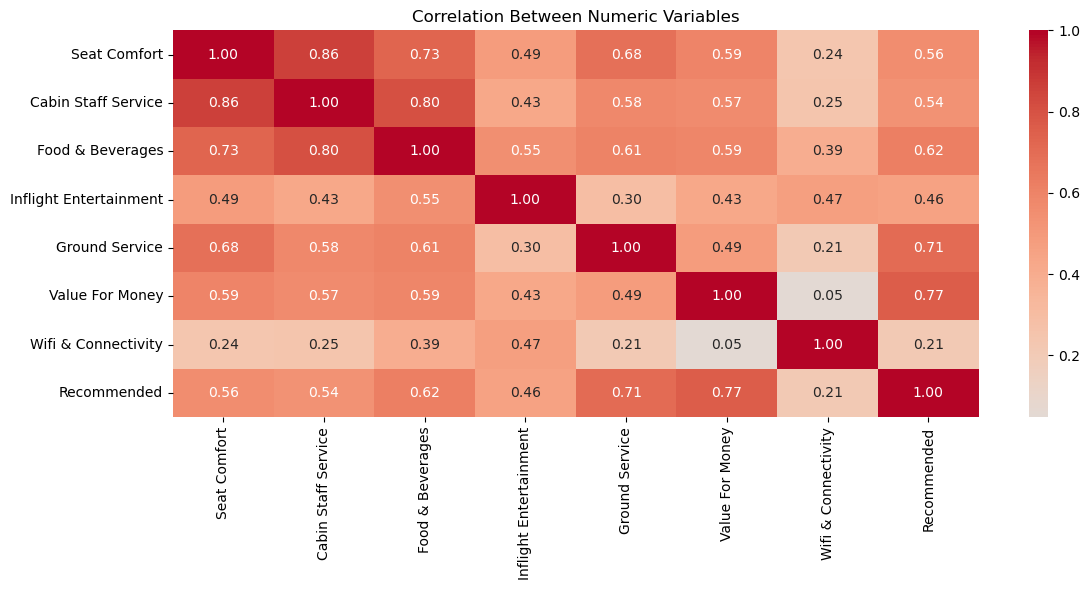

In [100]:
# Pick numeric columns
numeric_columns = data.select_dtypes(include="number").columns
# Plot correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data[numeric_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, center=0)
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", bbox_inches="tight")
plt.show()


### Grouped analysis

##### Count Verified flights

In [101]:
verified = data["Trip Verified"].value_counts()
verified

Trip Verified
Yes    773
No     118
Name: count, dtype: int64

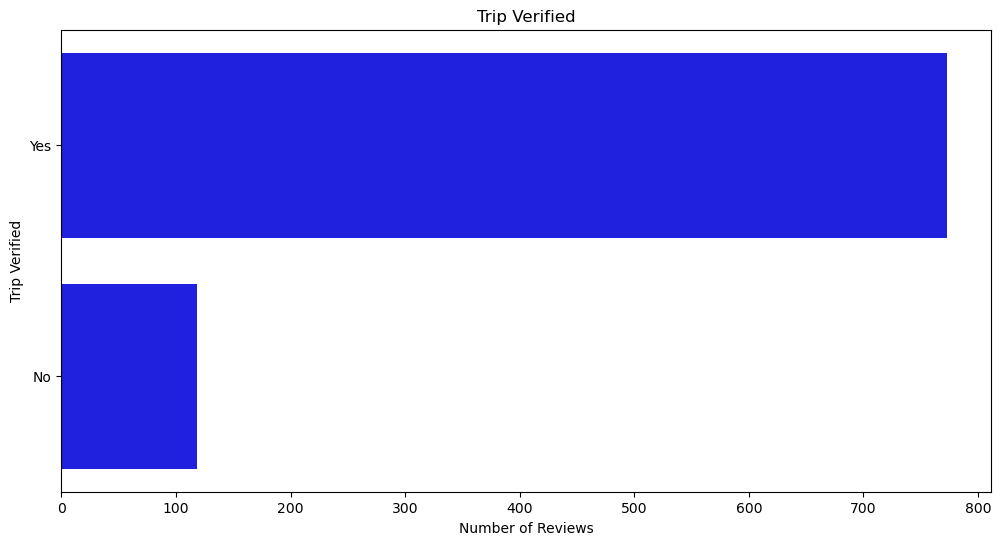

In [102]:
# Trip Verified
plt.figure(figsize=(12,6))
sns.barplot(
    x=verified.values,
    y=verified.index,
    color="blue"
)
plt.title("Trip Verified")
plt.xlabel("Number of Reviews")
plt.ylabel("Trip Verified")
plt.savefig("images/trip_verified.png", bbox_inches="tight")
plt.show()

In [103]:
top_seat_categories = data["Seat Type"].value_counts()
top_seat_categories

Seat Type
Economy Class      732
Business Class     146
Premium Economy      9
First Class          4
Name: count, dtype: int64

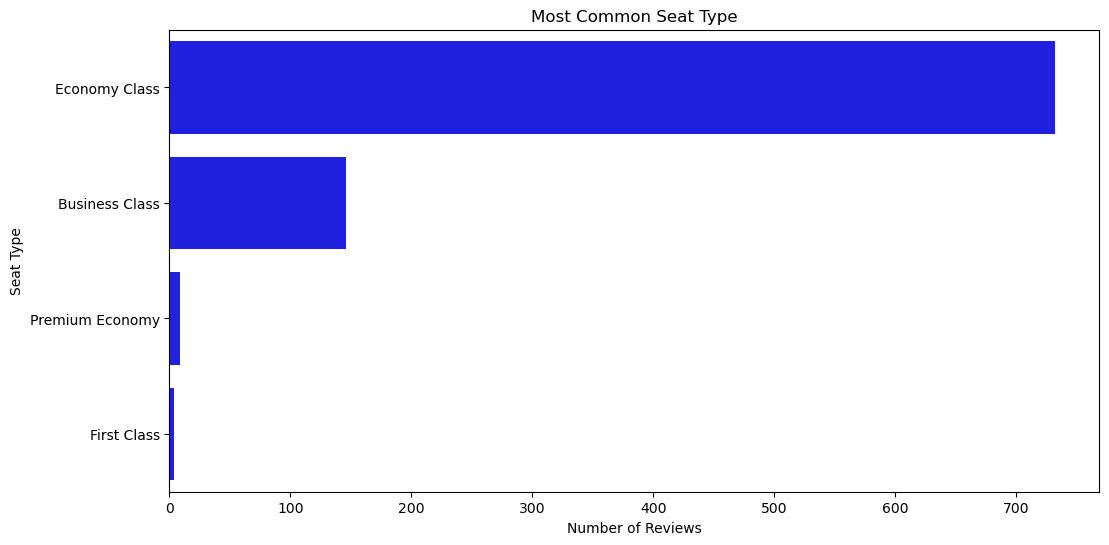

In [104]:
# Seat Type
plt.figure(figsize=(12,6))
sns.barplot(x=top_seat_categories.values, y=top_seat_categories.index, color="blue")
plt.title("Most Common Seat Type")
plt.xlabel("Number of Reviews")
plt.ylabel("Seat Type")
plt.savefig("images/seat_type.png", bbox_inches="tight")
plt.show()

##### Calculates average rating and display in decending order

In [105]:
# Columns to average
service_columns = [
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Ground Service",
    "Value For Money",
    "Recommended"
]

# Group by seat type and calculate mean
seat_group = data.groupby("Seat Type")[service_columns].mean()

# Sort by the first service column (Seat Comfort)
seat_group = seat_group.sort_values("Seat Comfort", ascending=False)

seat_group

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Recommended
Seat Type,,,,,,,
Premium Economy,3.555556,4.444444,4.444444,0.888889,4.555556,4.555556,0.888889
First Class,3.000000,1.000000,1.000000,1.000000,2.000000,2.000000,0.000000
Economy Class,2.289617,2.509563,1.831967,1.336066,1.916667,2.262295,0.154372
Business Class,1.938356,2.643836,2.034247,1.472603,1.486301,2.205479,0.143836


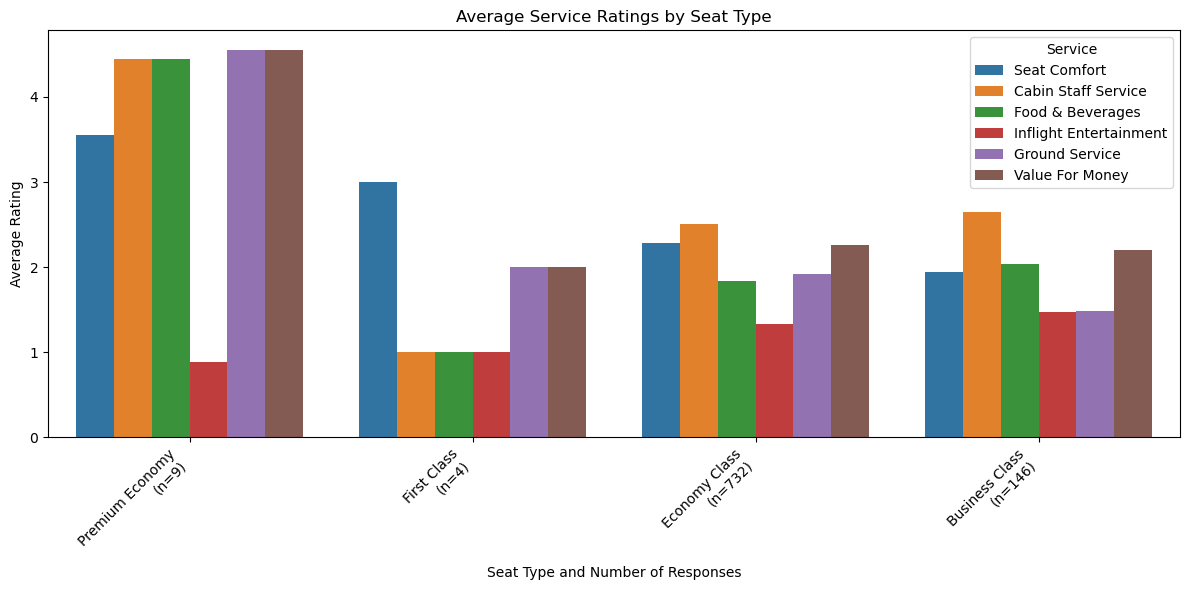

In [106]:
# Define the service rating columns to analyze
rating_columns = [
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Ground Service",
    "Value For Money"
]

# Reshape grouped seat data: convert wide format into long format for plotting
plot_data = seat_group[rating_columns].reset_index().melt(
    id_vars="Seat Type",          # Keep Seat Type as identifier
    var_name="Service",           # Column name for service type
    value_name="Average Rating"   # Column name for average rating values
)

# Count how many responses exist for each seat type
response_counts = data["Seat Type"].value_counts()

# Append response counts to seat type labels (e.g., "Economy\n(n=120)")
plot_data["Seat Type"] = (
    plot_data["Seat Type"].astype(str) + "\n(n=" + plot_data["Seat Type"].map(response_counts).astype(str) + ")"
)

# Set figure size for the plot
plt.figure(figsize=(12, 6))

# Create grouped bar plot: average ratings by seat type and service category
sns.barplot(
    data=plot_data,
    x="Seat Type",        # Seat type (with response count) on x-axis
    y="Average Rating",   # Average rating on y-axis
    hue="Service"         # Different colors for each service category
)

# Add chart title and axis labels
plt.title("Average Service Ratings by Seat Type")
plt.xlabel("Seat Type and Number of Responses")
plt.ylabel("Average Rating")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot as an image file
plt.savefig("images/seat_type_service.png", bbox_inches="tight")

# Display the plot
plt.show()


##### Calculate Top 10 routes per rating

In [107]:
route_mapping = {
    "Puerto Princesa to Cebu": "Domestic",
    "Cebu to Clark": "Domestic",
    "Manila to Cebu": "Domestic",
    "Dumaguete to Manila": "Domestic",
    "Cebu to Caticlan": "Domestic",
    "Manila to Iloilo": "Domestic",
    "Manila to Laoag International Airport": "Domestic",
    "Manila to Tagbilaran": "Domestic",
    "Legazpi to Manila": "Domestic",
    "Manila to Caticlan (Boracay)": "Domestic",
    "Cebu to Tacloban": "Domestic",
    "Cebu to Manila": "Domestic",
    "Manila to Bacolod": "Domestic",
    "Davao to Manila": "Domestic",
    "Siargao to Cebu": "Domestic",
    "Manila to Panglao": "Domestic",
    "Hanoi to Manila": "International Short-Haul Flights",
    "Manila to Nagoya": "International Short-Haul Flights",
    "Tokyo Narita to Cebu": "International Short-Haul Flights",
    "Jakarta to Manila": "International Short-Haul Flights",
    "Manila to Ho Chi Minh City": "International Short-Haul Flights",
    "Manila to Tokyo Narita": "International Short-Haul Flights",
    "Bangkok to Manila": "International Short-Haul Flights",
    "Dubai to Manila": "International Short-Haul Flights",
    "Manila to Fukuoka": "International Short-Haul Flights",
    "Singapore to Manila": "International Short-Haul Flights",
    "Manila to Jakarta": "International Short-Haul Flights",
    "Incheon via Manila": "International Short-Haul Flights",
    "Manila to Singapore": "International Short-Haul Flights",
    "Manila to Melbourne": "International Long-Haul Flights",
    "Singapore to Melbourne via Manila": "International Long-Haul Flights",
    "Los Angeles to Manila": "International Long-Haul Flights",
    "Manila to San Francisco": "International Long-Haul Flights",
    "Canada to Philippines": "International Long-Haul Flights",
    "Manila via Los Angeles": "International Long-Haul Flights",
    "Manila to Los Angeles": "International Long-Haul Flights",
    "Davao to San Francisco via Manila": "International Long-Haul Flights",
    "Sydney to Hong Kong via Manila": "International Long-Haul Flights",
    "Manila to Dubai": "International Long-Haul Flights",
    "Honolulu to Denpasar via Manila": "International Long-Haul Flights",
    "Los Angeles to Melbourne via Manila": "International Long-Haul Flights",
    "Del Carmen Siargao to Denpasar via Manila": "International Long-Haul Flights",
    "Vancouver to Bangkok via Manila": "International Long-Haul Flights",
    "Manila to Vancouver": "International Long-Haul Flights",
    "Vancouver to Manila": "International Long-Haul Flights",
    "Manila to London": "International Long-Haul Flights",
    "Tokyo to Bali via Manila": "International Long-Haul Flights",
    "Manila to Dammam": "International Long-Haul Flights",
    "Manila to Toronto": "International Long-Haul Flights",
    "Auckland to Osaka via Manila": "International Long-Haul Flights",
    "Bangkok to San Francisco via Manila": "International Long-Haul Flights",
    "Ho Chi Minh City to San Francisco via Manila": "International Long-Haul Flights",
    "Riyadh to Manila": "International Long-Haul Flights",
    "Sydney to Manila": "International Long-Haul Flights",
    "Brisbane to Manila": "International Long-Haul Flights",
    "Dubai to Melbourne via Manila": "International Long-Haul Flights",
    "Ho Chi Minh City to Los Angeles via Manila": "International Long-Haul Flights",
    "Kuala Lumpur to Caticlan via Manila": "International Long-Haul Flights",
    "Phnom Penh to San Francisco via Manila": "International Long-Haul Flights",
    "Sydney to Los Angeles via Manila": "International Long-Haul Flights",
    "Bangkok to Los Angeles via Manila": "International Long-Haul Flights",
    "San Francisco to Manila": "International Long-Haul Flights",
    "Melbourne to Cebu via Manila": "International Long-Haul Flights",
    "Los Angeles to Cebu via Manila": "International Long-Haul Flights",
    "Sydney to Cebu via Manila": "International Long-Haul Flights",
    "Honolulu to Manila": "International Long-Haul Flights",
    "Toronto to Manila via Vancouver": "International Long-Haul Flights",
    "London to Manila": "International Long-Haul Flights",
    "Melbourne to Manila": "International Long-Haul Flights",
    "Toronto to Kuala Lumpur via Manila": "International Long-Haul Flights",
    "Dammam to Manila": "International Long-Haul Flights",
    "Manila to Brisbane": "International Long-Haul Flights",
    "Los Angeles to Australia via Manila": "International Long-Haul Flights",
    "Los Angeles to Hong Kong via Manila": "International Long-Haul Flights",
    "Chicago to Manila": "International Long-Haul Flights",
    "Manila to Sydney": "International Long-Haul Flights",
    "Bangkok to London via Manila": "International Long-Haul Flights",
    "London to Kuala Lumpur via Manila": "International Long-Haul Flights",
    "San Francisco to Osaka via Manila": "International Long-Haul Flights",
    "Kuala Lumpur to Los Angeles via Manila": "International Long-Haul Flights",
    "Manila to Riyadh": "International Long-Haul Flights",
    "Manila to London Heathrow": "International Long-Haul Flights",
    "New York to Manila": "International Long-Haul Flights",
    "Philippines to Toronto": "International Long-Haul Flights",
    "Dubai to Hong Kong via Manila": "International Long-Haul Flights",
    "Kuala Lumpur to Vancouver via Manila": "International Long-Haul Flights",
    "Vancouver to Singapore via Manila": "International Long-Haul Flights",
    "Legazpi to Riyadh via Manila": "International Long-Haul Flights",
    "Singapore to Vancouver via Manila": "International Long-Haul Flights",
    "Manila to New York": "International Long-Haul Flights",
    "Bangkok to Toronto via Manila": "International Long-Haul Flights"
}

data["Route Category"] = data["Route"].map(route_mapping).fillna("Unknown")
data[["Route", "Route Category"]].drop_duplicates().sort_values("Route")

,Route,Route Category
341,Auckland to Osaka via Manila,International Long-Haul Flights
632,Bangkok to London via Manila,International Long-Haul Flights
828,Bangkok to London via Manila,Unknown
495,Bangkok to Los Angeles via Manila,International Long-Haul Flights
387,Bangkok to Manila,International Short-Haul Flights
...,...,...
523,Toronto to Manila via Vancouver,International Long-Haul Flights
223,Vancouver to Bangkok via Manila,International Long-Haul Flights
333,Vancouver to Manila,International Long-Haul Flights
822,Vancouver to Singapore via Manila,International Long-Haul Flights


In [108]:
# Separate routes into tables by route category
data["Route"] = data["Route"].astype("string")


domestic_routes = (
    data.loc[data["Route Category"] == "Domestic", ["Route", "Route Category"]]
 
)

short_haul_routes = (
    data.loc[data["Route Category"] == "International Short-Haul Flights", ["Route", "Route Category"]]
)
short_haul_routes

long_haul_routes = (
    data.loc[data["Route Category"] == "International Long-Haul Flights", ["Route", "Route Category"]]

)
long_haul_routes

unknown_routes = (
    data.loc[data["Route Category"] == "Unknown", ["Route", "Route Category"]]
)
unknown_routes

print("Domestic")
display(domestic_routes)

print("International Short-Haul Flights")
display(short_haul_routes)

print("International Long-Haul Flights")
display(long_haul_routes)

print("Unknown")
display(unknown_routes)


Domestic


,Route,Route Category
469,Puerto Princesa to Cebu,Domestic
504,Cebu to Clark,Domestic
505,Manila to Cebu,Domestic
509,Dumaguete to Manila,Domestic
534,Manila to Panglao,Domestic
538,Legazpi to Manila,Domestic
539,Manila to Caticlan (Boracay),Domestic
550,Puerto Princesa to Cebu,Domestic
585,Cebu to Clark,Domestic
586,Manila to Cebu,Domestic


International Short-Haul Flights


,Route,Route Category
5,Hanoi to Manila,International Short-Haul Flights
14,Hanoi to Manila,International Short-Haul Flights
23,Hanoi to Manila,International Short-Haul Flights
32,Hanoi to Manila,International Short-Haul Flights
41,Hanoi to Manila,International Short-Haul Flights
...,...,...
847,Manila to Nagoya,International Short-Haul Flights
851,Manila to Tokyo Narita,International Short-Haul Flights
863,Tokyo Narita to Cebu,International Short-Haul Flights
865,Jakarta to Manila,International Short-Haul Flights


International Long-Haul Flights


,Route,Route Category
0,Manila to Melbourne,International Long-Haul Flights
1,Singapore to Melbourne via Manila,International Long-Haul Flights
2,Los Angeles to Manila,International Long-Haul Flights
3,Manila to San Francisco,International Long-Haul Flights
4,Canada to Philippines,International Long-Haul Flights
...,...,...
885,Los Angeles to Manila,International Long-Haul Flights
886,Riyadh to Manila,International Long-Haul Flights
887,Melbourne to Manila,International Long-Haul Flights
888,London to Kuala Lumpur via Manila,International Long-Haul Flights


Unknown


,Route,Route Category
220,Del Carme Siago to Denpasar via Manila,Unknown
221,Manila to Tagbilaran,Unknown
238,Del Carme Siago to Denpasar via Manila,Unknown
239,Manila to Tagbilaran,Unknown
256,Del Carme Siago to Denpasar via Manila,Unknown
...,...,...
814,Philippines to Toronto,Unknown
824,Manila to Singapore,Unknown
828,Bangkok to London via Manila,Unknown
843,Manila to Melbourne,Unknown


In [109]:
data

,Aircraft,Type Of Traveller,Trip Verified,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Wifi & Connectivity,Recommended,Route Category
0,Unknown,Solo Leisure,Yes,Business Class,Manila to Melbourne,2022-11-01,0.0,0.0,0.0,0.0,1.0,1,0.0,0,International Long-Haul Flights
1,A321 / A330,Couple Leisure,Yes,Business Class,Singapore to Melbourne via Manila,2022-10-01,2.0,3.0,2.0,2.0,1.0,3,0.0,0,International Long-Haul Flights
2,Unknown,Couple Leisure,Yes,Economy Class,Los Angeles to Manila,2022-04-01,0.0,0.0,0.0,0.0,0.0,3,0.0,0,International Long-Haul Flights
3,Unknown,Solo Leisure,No,Economy Class,Manila to San Francisco,2022-11-01,1.0,1.0,1.0,1.0,1.0,1,1.0,0,International Long-Haul Flights
4,Unknown,Family Leisure,Yes,Economy Class,Canada to Philippines,2022-11-01,3.0,3.0,3.0,3.0,1.0,1,3.0,0,International Long-Haul Flights
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,A330,Solo Leisure,No,Economy Class,Riyadh to Manila,2020-01-01,3.0,5.0,5.0,0.0,5.0,5,4.0,1,International Long-Haul Flights
887,A330-300,Business,Yes,Economy Class,Melbourne to Manila,2020-01-01,4.0,5.0,5.0,4.0,2.0,5,4.0,1,International Long-Haul Flights
888,Unknown,Solo Leisure,Yes,Economy Class,London to Kuala Lumpur via Manila,2020-03-01,0.0,0.0,0.0,0.0,0.0,1,0.0,0,International Long-Haul Flights
889,Unknown,Solo Leisure,Yes,Economy Class,Manila to Bacolod,2020-02-01,4.0,4.0,0.0,0.0,1.0,3,0.0,0,Domestic


In [110]:
# Average ratings by Route
route_group = data.groupby("Route")[[
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Ground Service",
    "Value For Money",
    "Recommended"
]].mean()

route_group

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Recommended
Route,,,,,,,
Auckland to Osaka via Manila,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
Bangkok to London via Manila,4.000000,4.000000,0.000000,0.000000,3.000000,1.000000,0.000000
Bangkok to London via Manila,4.000000,3.000000,1.000000,5.000000,3.000000,2.000000,0.000000
Bangkok to Los Angeles via Manila,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000
Bangkok to Manila,2.636364,4.272727,3.363636,2.454545,2.545455,2.545455,0.363636
...,...,...,...,...,...,...,...
Toronto to Kuala Lumpur via Manila,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
Toronto to Manila via Vancouver,3.000000,4.000000,3.000000,4.000000,2.000000,1.000000,0.000000
Vancouver to Bangkok via Manila,2.000000,4.000000,3.000000,1.000000,1.000000,2.000000,0.000000


In [111]:
# Sort by Seat Comfort and show top 10
top_routes = route_group.sort_values("Seat Comfort", ascending=False).head(10)

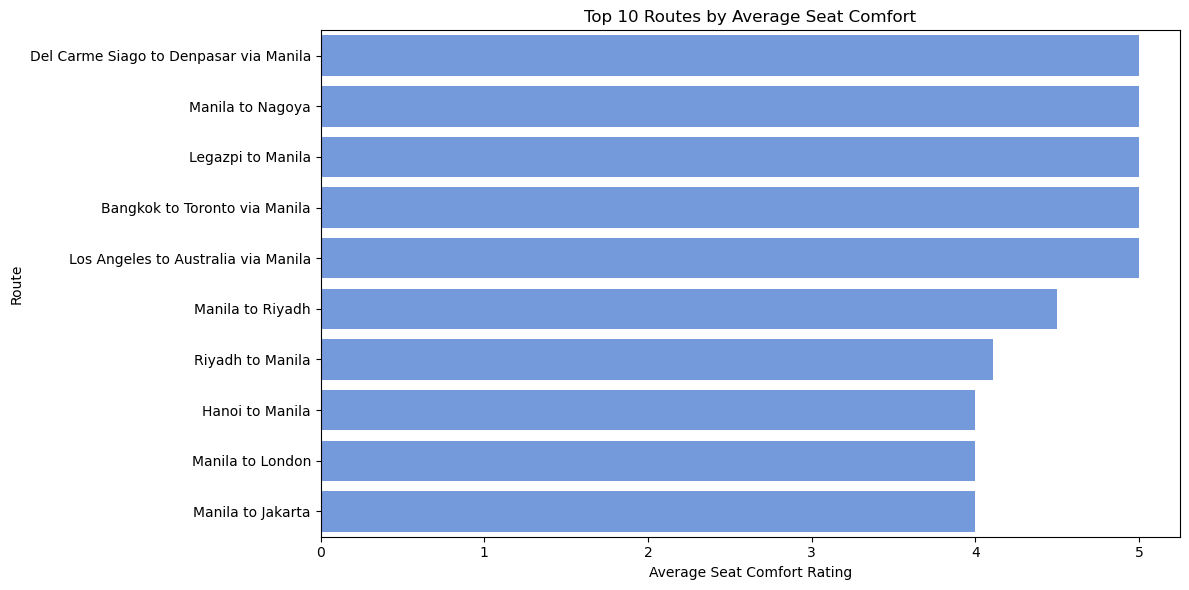

In [112]:
# Plot bar chart
plt.figure(figsize=(12,6))
top_routes_plot = top_routes.reset_index()

sns.barplot(
    data=top_routes_plot,
    x="Seat Comfort",
    y="Route",
    color="cornflowerblue"
)
plt.title("Top 10 Routes by Average Seat Comfort")
plt.xlabel("Average Seat Comfort Rating")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig("images/seat_comfort.png", bbox_inches="tight")
plt.show()


##### Export Summary

In [113]:
# Export grouped summaries
if "seat_group" in locals():
    seat_group.to_csv("seat_group_summary.csv")

if "verified_group" in locals():
    verified.to_csv("verified_group_summary.csv")

if "route_group" in locals():
    route_group.to_csv("route_group_summary.csv")

### Outlier analysis using the IQR method

Interquartile Range (IQR): The range between the first quartile (Q1) and the third quartile (Q3). It is less sensitive to extreme values than the range. To compute IQR, calculate the values of the first and third quartile by arranging the data in ascending order. Then, calculate the mean of each half of the dataset.

Quartiles divide a data set into four equal parts, each containing 25% of the data. They help to understand the spread and center of the data. As an important concept in statistics, quartiles are used to analyze large data sets by highlighting values near the middle. This method is particularly useful for identifying outliers and comparing different data sets.

###### Interquartile Range

###### Interquartile Range is the distance between the first quartile and the third quartile. It is also known as a mid-spread. It helps us to calculate variation for the data, which is divided into quartiles. The formula for calculating the Interquartile range is given by,

###### Interquartile Range (iqr) = q3 - q1

###### Since the IQR focuses on the middle 50% of the data, any values that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are typically considered outliers.

In [114]:
outlier_summary = []

for column in data.select_dtypes(include="number").columns:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    # Bounds
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Count outliers
    count = ((data[column] < lower) | (data[column] > upper)).sum()

    outlier_summary.append([column, count, lower, upper])

# Turn into DataFrame
outlier_summary = pd.DataFrame(outlier_summary,
                               columns=["Column","Outliers","Lower Bound","Upper Bound"])

outlier_summary


,Column,Outliers,Lower Bound,Upper Bound
0,Seat Comfort,0,-2.0,6.0
1,Cabin Staff Service,0,-3.5,8.5
2,Food & Beverages,0,-2.0,6.0
3,Inflight Entertainment,0,-4.5,7.5
4,Ground Service,0,-2.0,6.0
5,Value For Money,0,-2.0,6.0
6,Wifi & Connectivity,110,-1.5,2.5
7,Recommended,142,0.0,0.0


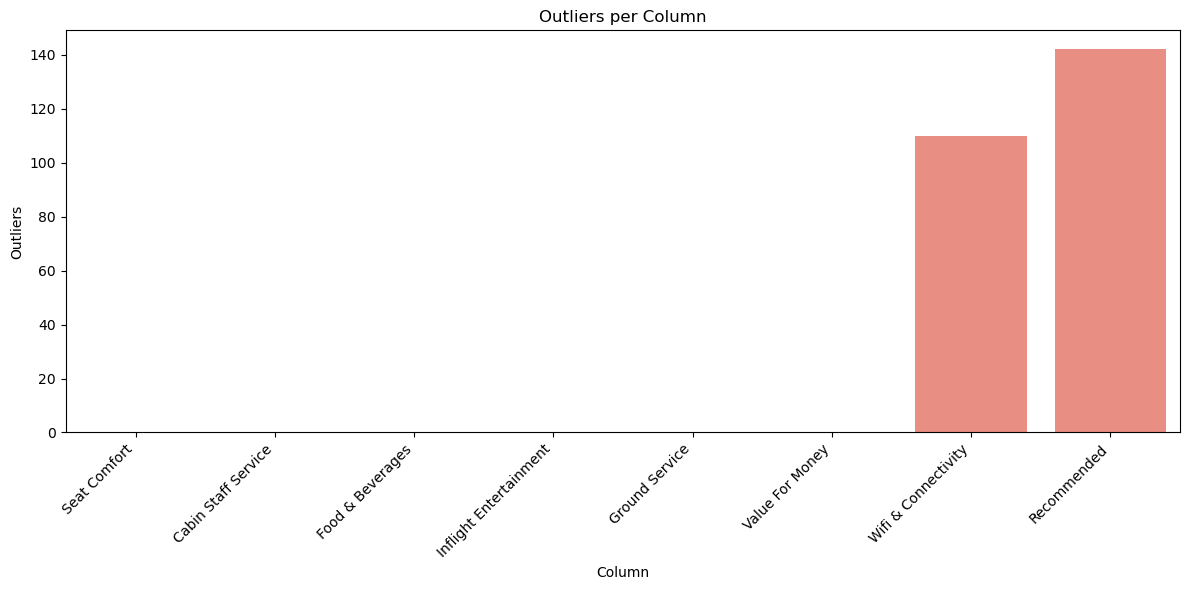

In [115]:
# Bar chart of outlier counts
plt.figure(figsize=(12,6))
sns.barplot(x="Column", y="Outliers", data=outlier_summary, color="salmon")
plt.title("Outliers per Column")
plt.xticks(rotation=45, ha="right")
plt.savefig("images/outliers_per_column.png", bbox_inches="tight")
plt.tight_layout()

### Numeric distributions

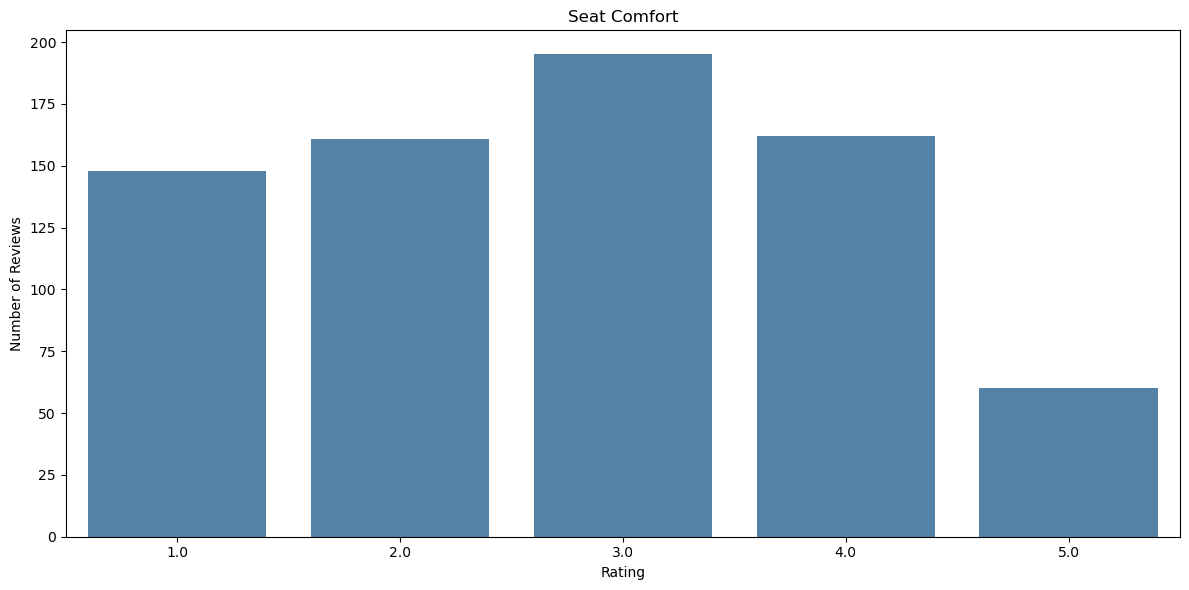

In [116]:
# Seat Comfort
seat_comfort_counts = (
    data.loc[data["Seat Comfort"] > 0, "Seat Comfort"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=seat_comfort_counts.index,
    y=seat_comfort_counts.values,
    color="steelblue"
)

plt.title("Seat Comfort")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/seat_comfort_numerical.png", bbox_inches="tight")
plt.show()

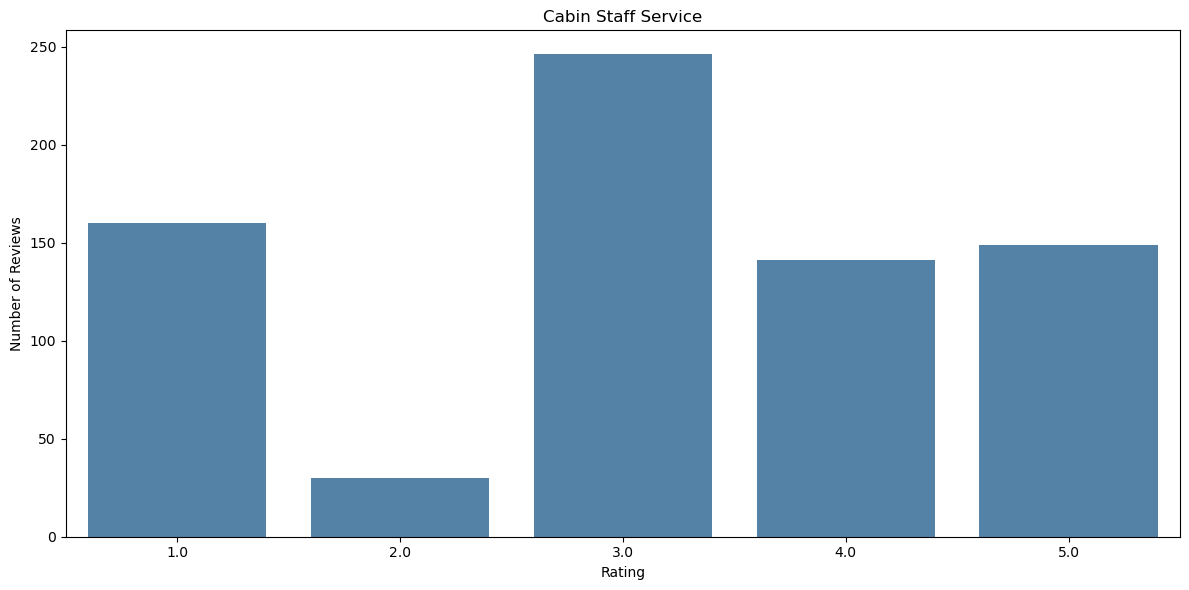

In [117]:
# Cabin Staff Service
cabin_staff_counts = (
    data.loc[data["Cabin Staff Service"] > 0, "Cabin Staff Service"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=cabin_staff_counts.index,
    y=cabin_staff_counts.values,
    color="steelblue"
)

plt.title("Cabin Staff Service")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/cabin_staff_service_numerical.png", bbox_inches="tight")
plt.show()

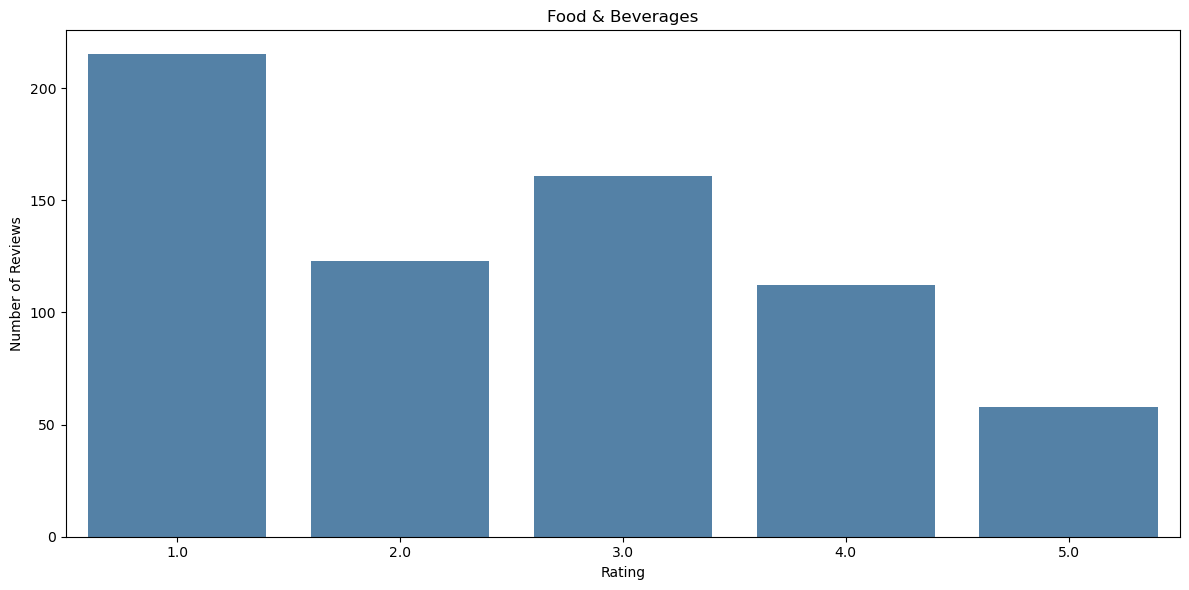

In [118]:
# Food & Beverages
food_counts = (
    data.loc[data["Food & Beverages"] > 0, "Food & Beverages"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=food_counts.index,
    y=food_counts.values,
    color="steelblue"
)

plt.title("Food & Beverages")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/food_beverages_numerical.png", bbox_inches="tight")
plt.show()

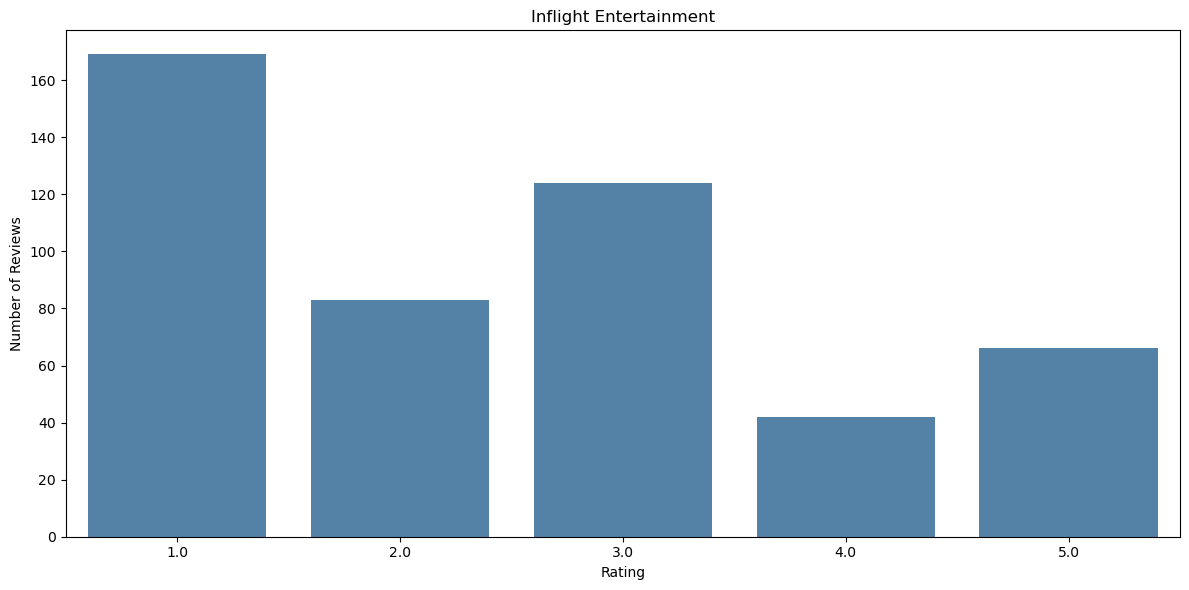

In [119]:
# Inflight Entertainment
entertainment_counts = (
    data.loc[data["Inflight Entertainment"] > 0, "Inflight Entertainment"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=entertainment_counts.index,
    y=entertainment_counts.values,
    color="steelblue"
)

plt.title("Inflight Entertainment")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/inflight_entertainment_numerical.png", bbox_inches="tight")
plt.show()

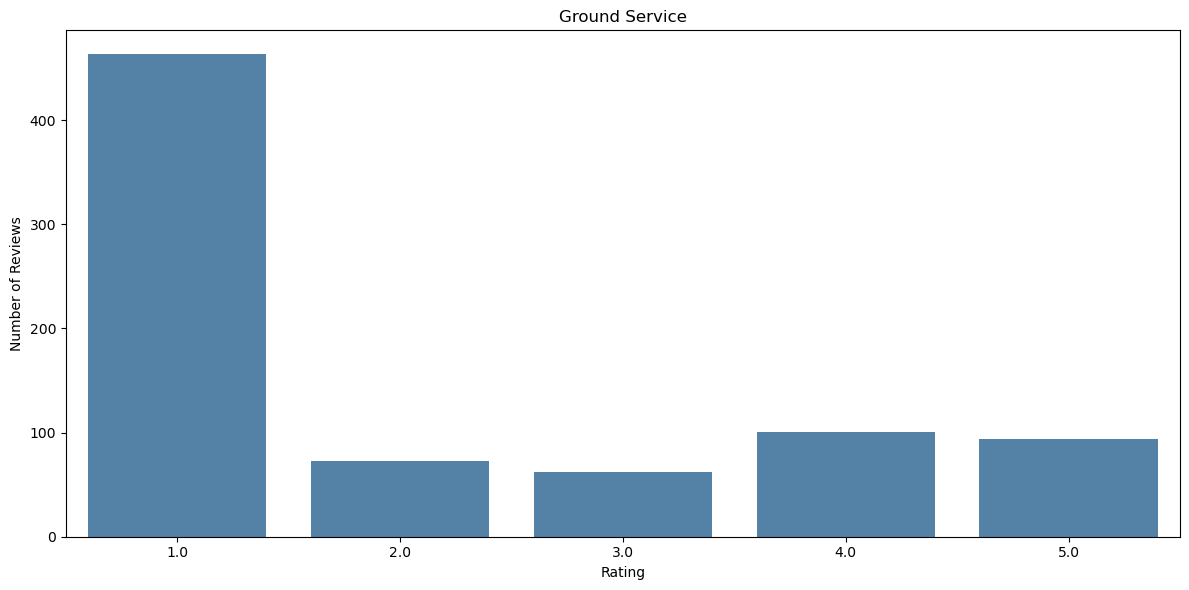

In [120]:
#Ground Service
ground_service_counts = (
    data.loc[data["Ground Service"] > 0, "Ground Service"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=ground_service_counts.index,
    y=ground_service_counts.values,
    color="steelblue"
)

plt.title("Ground Service")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/ground_service_numerical.png", bbox_inches="tight")
plt.show()

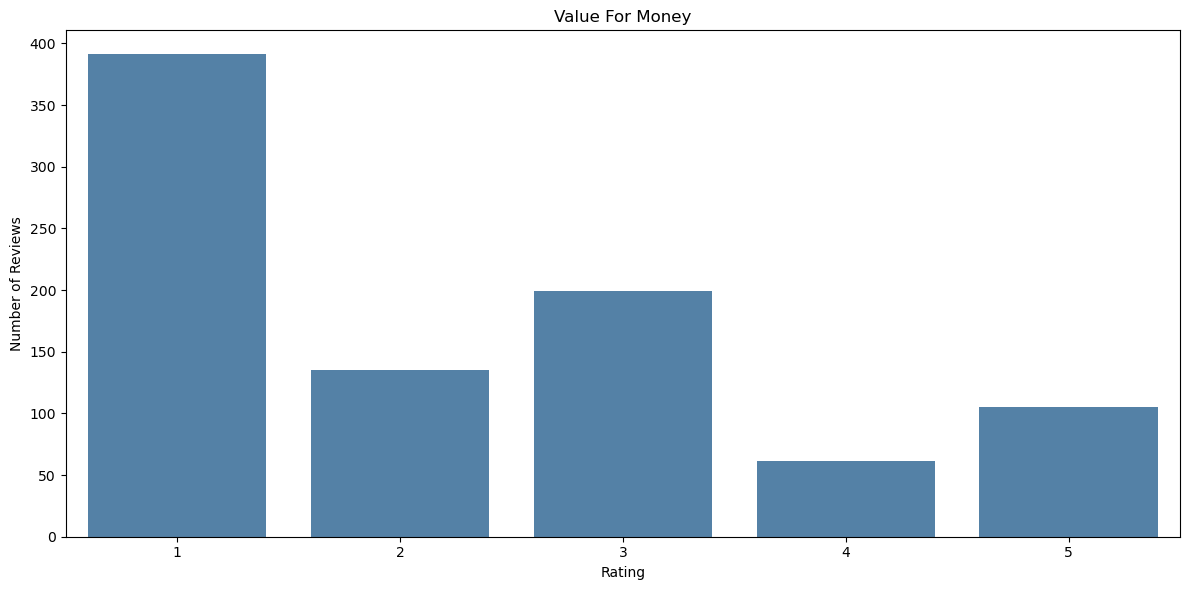

In [121]:
# Value For Money
value_counts = (
    data.loc[data["Value For Money"] > 0, "Value For Money"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=value_counts.index,
    y=value_counts.values,
    color="steelblue"
)

plt.title("Value For Money")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/value_for_money_numerical.png", bbox_inches="tight")
plt.show()

##### Top Aircraft

In [122]:
top_aircraft = data["Aircraft"].value_counts()

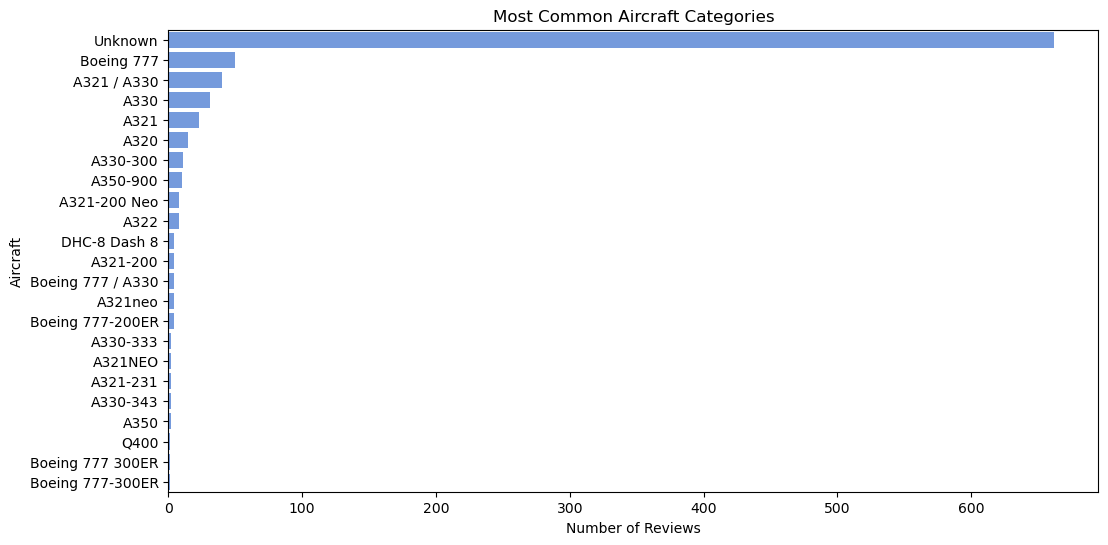

In [123]:
#  Top Aircraft
plt.figure(figsize=(12,6))
sns.barplot(x=top_aircraft.values, y=top_aircraft.index, color="cornflowerblue")
plt.title("Most Common Aircraft Categories")
plt.xlabel("Number of Reviews")
plt.ylabel("Aircraft")
plt.savefig("images/top_aircraft.png", bbox_inches="tight")
plt.show()


### Monthly rating trends

In [124]:
# Create Year-Month column
data["YearMonth"] = data["Date Flown"].dt.to_period("M")

# Average ratings per month (last 12 months)
trend = data.groupby("YearMonth")[[
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Ground Service",
    "Value For Money"
]].mean()

trend

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money
YearMonth,,,,,,
2019-01,4.000000,5.000000,4.000000,2.000000,4.000000,4.000000
2019-02,4.000000,5.000000,3.000000,0.000000,4.000000,5.000000
2019-04,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000
2019-05,1.500000,2.500000,1.000000,0.000000,2.500000,1.000000
2019-06,3.666667,3.888889,3.444444,3.444444,3.444444,3.666667
2019-07,1.714286,1.571429,1.857143,1.071429,1.071429,1.642857
2019-08,3.421053,3.789474,3.105263,2.789474,2.947368,3.526316
2019-09,3.700000,4.300000,3.700000,3.400000,3.400000,3.900000
2019-10,4.000000,3.666667,3.333333,5.000000,4.333333,4.333333


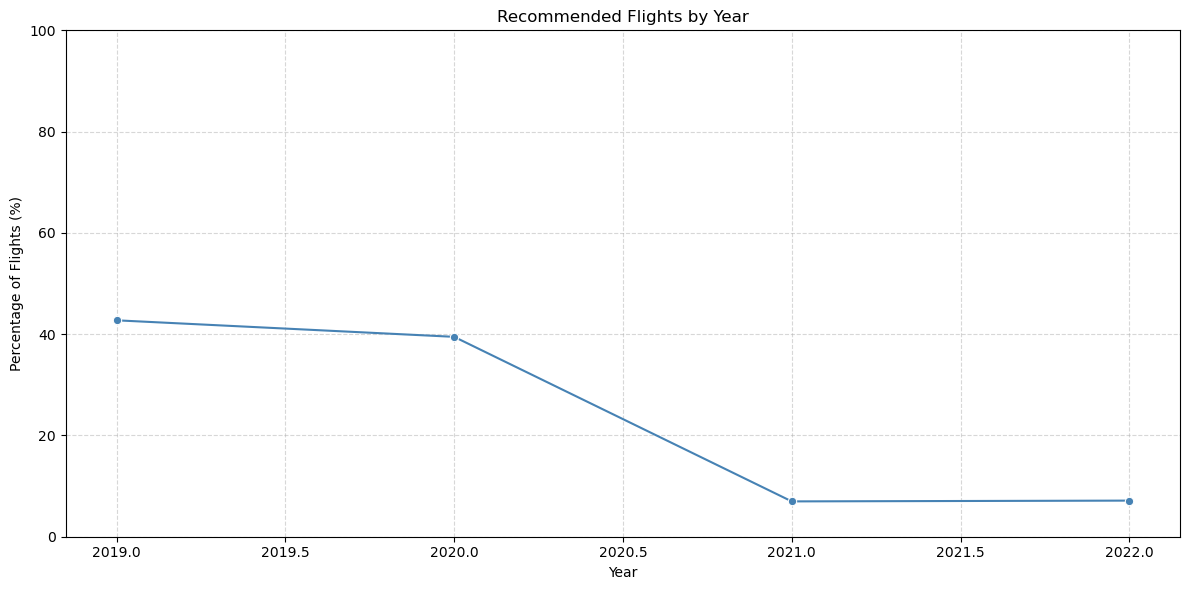

In [125]:
# Compare recommendations by year

# Count recommendations for each year (0 = Not Recommended, 1 = Recommended)
yearly_counts = pd.crosstab(
    data["Date Flown"].dt.year,
    data["Recommended"]
)

# Keep only the "Recommended" (1) column
yearly_recommended = yearly_counts[1]

# Convert counts to percentages
yearly_percentages = (yearly_recommended / yearly_counts.sum(axis=1)) * 100

# Prepare the data for Seaborn
yearly_plot = yearly_percentages.reset_index()
yearly_plot.columns = ["Year", "Percentage"]

# Create the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_plot,
    x="Year",
    y="Percentage",
    marker="o",          # add markers for clarity
    color="steelblue"
)

plt.title("Recommended Flights by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Flights (%)")
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("images/recommended_by_year.png", bbox_inches="tight")
plt.show()

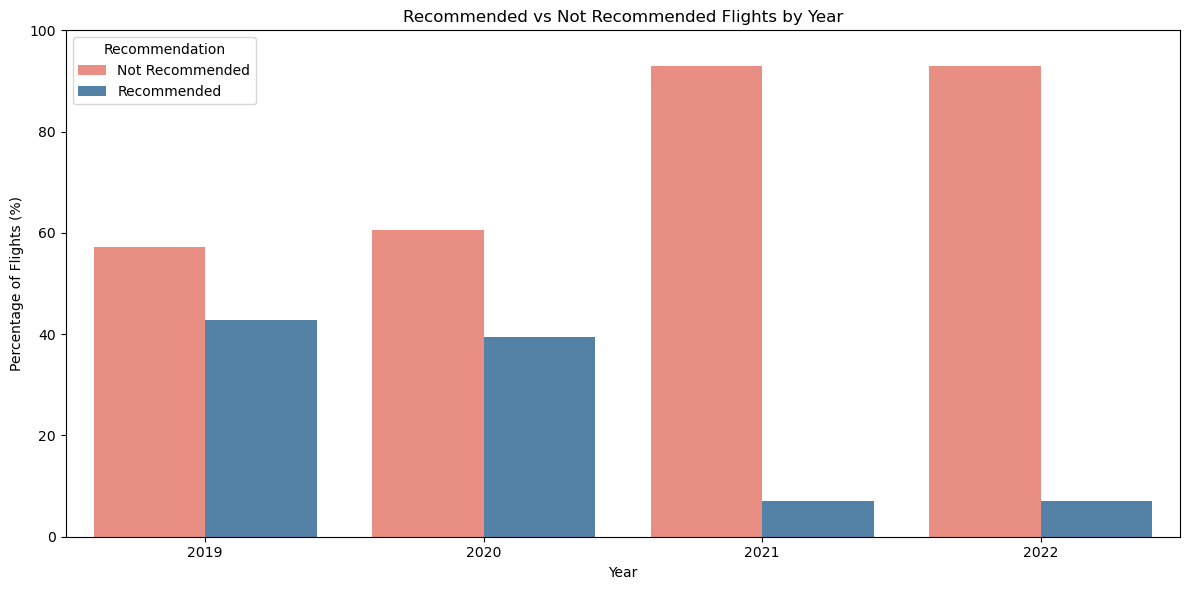

In [126]:
# Compare recommendations by year

# Count recommendations for each year
yearly_counts = pd.crosstab(
    data["Date Flown"].dt.year,
    data["Recommended"]
)

# Rename the recommendation columns
yearly_counts.columns = ["Not Recommended", "Recommended"]

# Convert counts to percentages
yearly_percentages = yearly_counts.div(
    yearly_counts.sum(axis=1),
    axis=0
) * 100

# Prepare the data for Seaborn
yearly_plot = yearly_percentages.reset_index().melt(
    id_vars="Date Flown",
    var_name="Recommendation",
    value_name="Percentage"
)

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=yearly_plot,
    x="Date Flown",
    y="Percentage",
    hue="Recommendation",
    palette={"Not Recommended": "salmon", "Recommended": "steelblue"}
)

plt.title("Recommended vs Not Recommended Flights by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Flights (%)")
plt.ylim(0, 100)
plt.legend(title="Recommendation")
plt.tight_layout()
plt.savefig("images/recommended_vs_not_recommended_by_year.png", bbox_inches="tight")
plt.show()

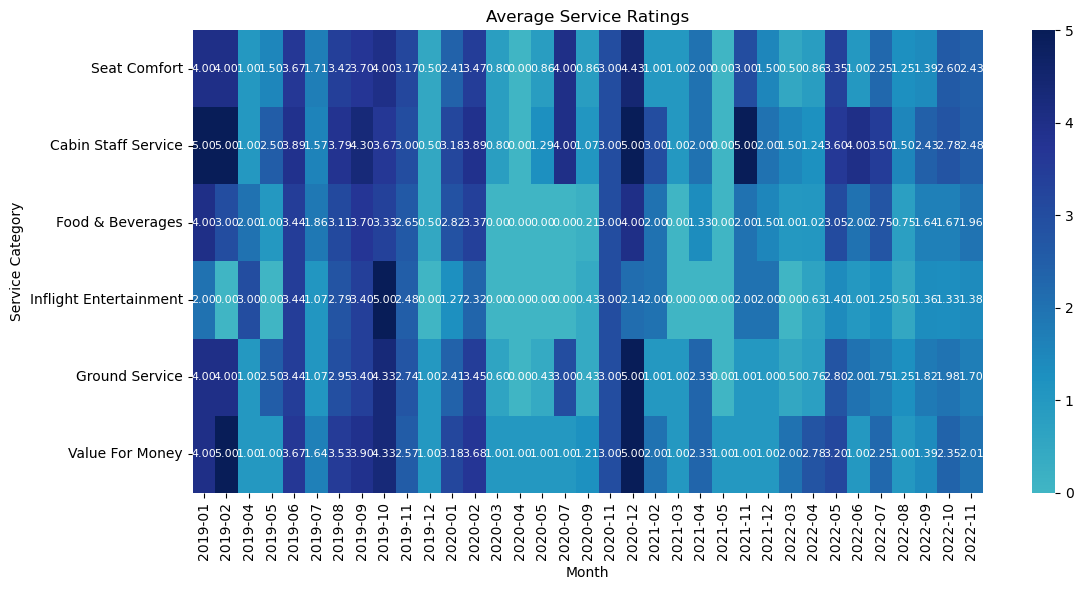

In [127]:
plt.figure(figsize=(12,6))
sns.heatmap(
    trend.T,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    annot_kws={"size":8},# smaller font so numbers fit
    center = 0

)
plt.title("Average Service Ratings")
plt.xlabel("Month")
plt.ylabel("Service Category")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("images/correlation_heatmap_ratings.png", bbox_inches="tight")
plt.show()


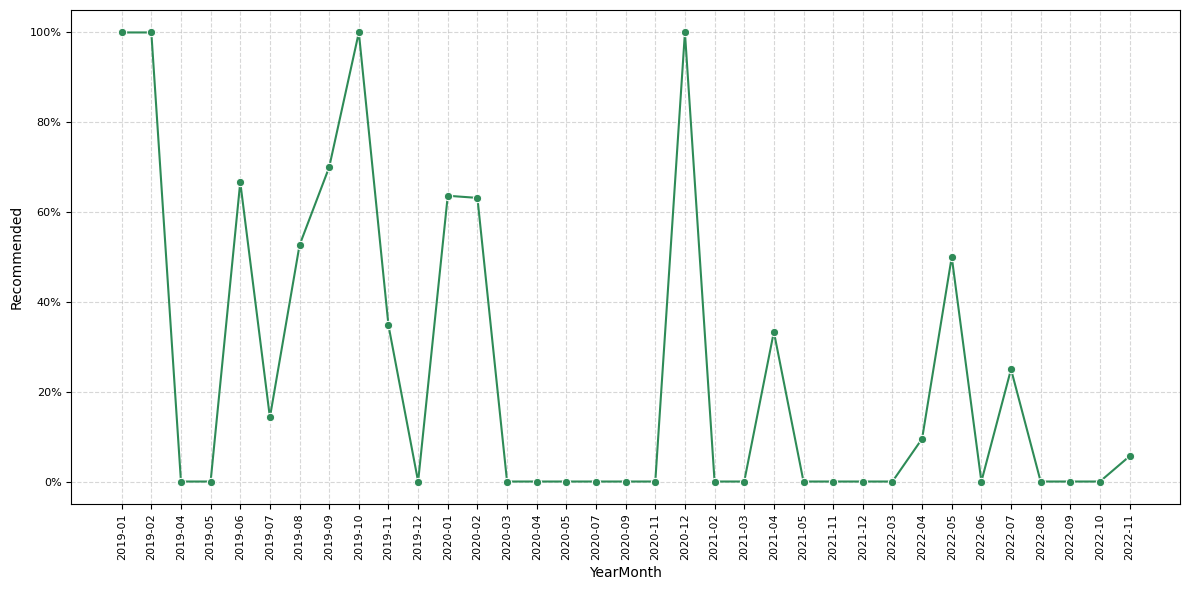

In [128]:
import matplotlib.ticker as mtick
trend["Recommended"] = (data.groupby("YearMonth")["Recommended"].mean().reindex(trend.index))
plt.figure(figsize=(12,6))
sns.lineplot(
    data=trend,
    x=trend.index.astype(str),
    y="Recommended",
    marker="o",
    color="seagreen"
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("images/ratings.png", bbox_inches="tight")
plt.show()

##### Recommended-flight analysis

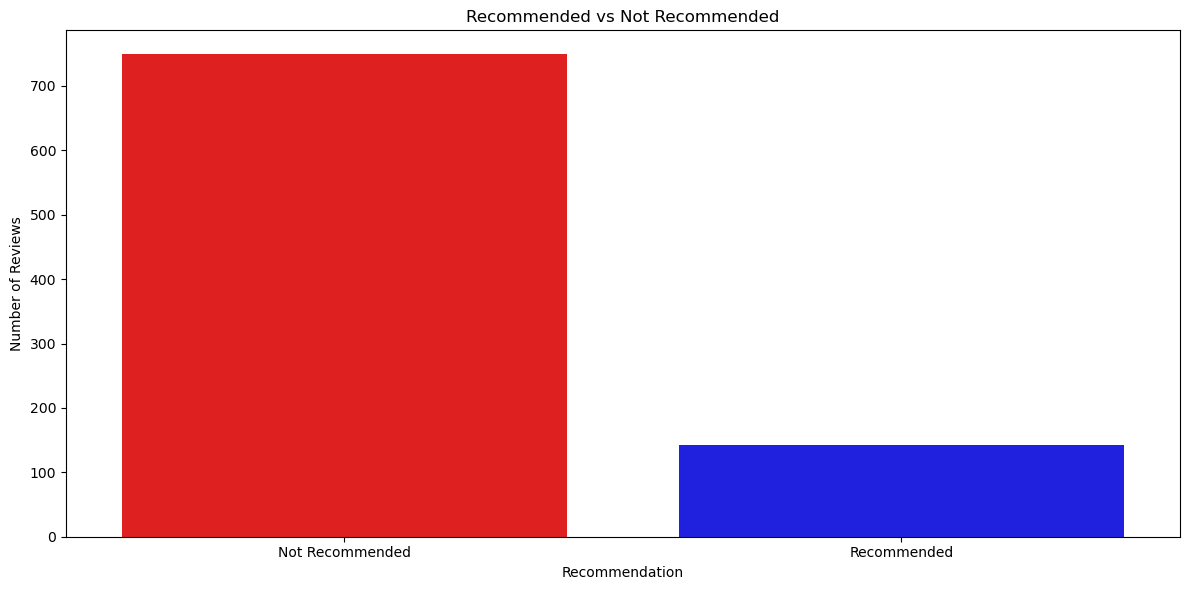

In [129]:
data["Recommended"].value_counts()
plt.figure(figsize=(12,6))
counts = data["Recommended"].value_counts()
sns.barplot(
    x=["Not Recommended", "Recommended"],
    y=counts.values,
    hue=["Not Recommended", "Recommended"],
    palette=["red", "blue"],
    legend=False
)

plt.title("Recommended vs Not Recommended")
plt.xlabel("Recommendation")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("images/bar_recommendation.png", bbox_inches="tight")
plt.show()


##### Percentage of recommended flights

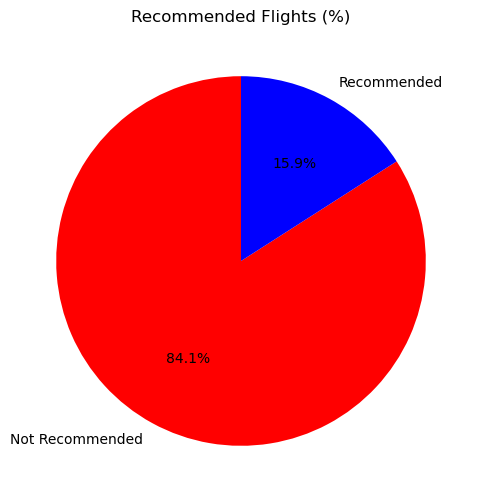

In [130]:
# Calculate percentages
recommendation_percentage = (
    data["Recommended"]
    .map({1:"Recommended", 0:"Not Recommended"})
    .value_counts(normalize=True) * 100
)

# Show percentages
recommendation_percentage.round(2)

# Plot pie chart

plt.figure(figsize=(12, 6))
plt.pie(
    recommendation_percentage.values,
    labels=recommendation_percentage.index,
    autopct="%1.1f%%",
    colors=["red", "blue"],
    startangle=90
)
plt.title("Recommended Flights (%)")
plt.savefig("images/recommendation_pie.png", bbox_inches="tight")
plt.show()


##### Compare average service ratings by recommendation

In [131]:
# Average ratings by recommendation
recommended_service_means = data.groupby("Recommended")[[
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Ground Service",
    "Value For Money"
]].mean()

recommended_service_means

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money
Recommended,,,,,,
0,1.870494,2.136182,1.461949,1.033378,1.395194,1.813084
1,4.239437,4.697183,4.133803,3.035211,4.394366,4.711268


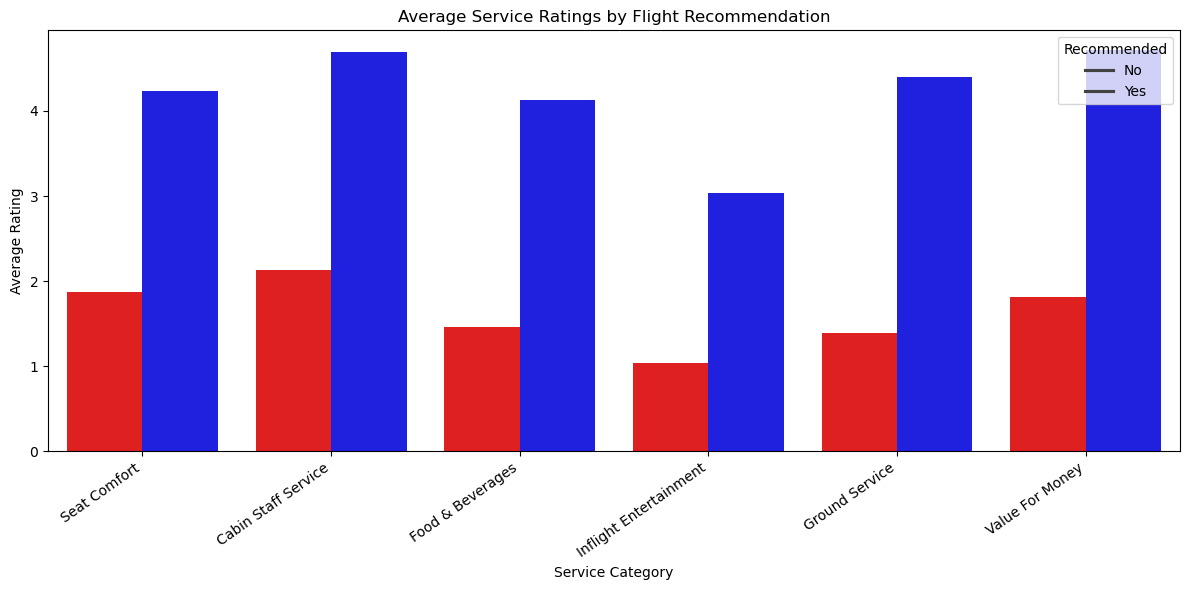

In [132]:
plot_data = recommended_service_means.reset_index().melt(
    id_vars="Recommended",
    var_name="Service",
    value_name="Average Rating"
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=plot_data,
    x="Service",
    y="Average Rating",
    hue="Recommended",
    palette={0:"red", 1:"blue"}   # 0 = Not Recommended, 1 = Recommended
)

plt.title("Average Service Ratings by Flight Recommendation")
plt.xlabel("Service Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Recommended", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig("images/recommended_service.png", bbox_inches="tight")
plt.show()


### Save cleaned data

In [133]:
data.to_csv("PALreview2_cleaned.csv", index=False)

print("Cleaned dataset saved as PALreview2_cleaned.csv")
print(f"Final dataset shape: {data.shape}")

Cleaned dataset saved as PALreview2_cleaned.csv
Final dataset shape: (891, 16)
